# Authors

- David Robredo Manuel
- Duarte Novas Álvarez
- Rubén González Braña

## Imports

In [5]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import visualkeras

from keras.callbacks import EarlyStopping

from keras.utils import to_categorical

In [6]:
print("Available Physical Devices: ", tf.config.list_physical_devices())

Available Physical Devices:  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Functions

In [7]:
def show_image(image):

    plt.imshow(image)
    plt.axis("off")
    plt.show()

Here we define the functions that we used to apply feature extraction to the dataset. We use a cany edge detector to mark the edges and a sift transform.

In [8]:
import copy
import cv2
import numpy as np

def canny_edge_dataset(dataset):
    canny_dataset = []
    for img_pre in dataset:
        try:
            img = copy.deepcopy(img_pre)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            edges = cv2.Canny(gray, 150, 300)
            img[edges == 255] = (255, 0, 0)
            canny_dataset.append(img)
        except:
            print("Couldn't process image")

    return np.array(canny_dataset)


def sift_transform_dataset(dataset):
    sift_dataset = []
    for img_pre in dataset:
        try:
            img = copy.deepcopy(img_pre)
            sift = cv2.SIFT_create()
            keypoints = sift.detect(img, None)
            img_keypoints = cv2.drawKeypoints(img, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
            sift_dataset.append(img_keypoints)
        except:
            print("Couldn't process image")
    
    return np.array(sift_dataset)

## Preprocessing

#### LOADING DATA

We load the data and divide it into train and test. Also, we assert that there are the correct number of instances in each group.

In [9]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar100.load_data(label_mode="coarse")
assert X_train.shape == (50000, 32, 32, 3)
assert X_test.shape == (10000, 32, 32, 3)
assert y_train.shape == (50000, 1)
assert y_test.shape == (10000, 1)

##### Feature Extraction: Canny Edge Detection

In [10]:
X_train_canny_edge = canny_edge_dataset(X_train)
X_test_canny_edge = canny_edge_dataset(X_test)

Show an example image of the dataset

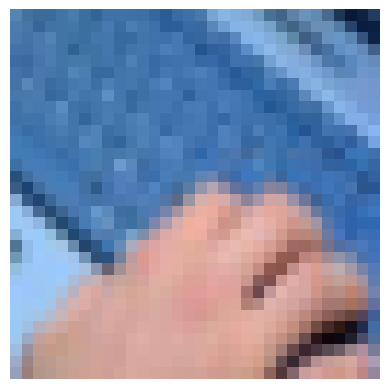

In [11]:
show_image(X_train[10])

##### Feature Extraction: SIFT Transform

In [12]:
X_train_sift_transform = sift_transform_dataset(X_train)
X_test_sift_transform = sift_transform_dataset(X_test)

Here are shown the original image and the image after processing it with sift transform and canny edge detector

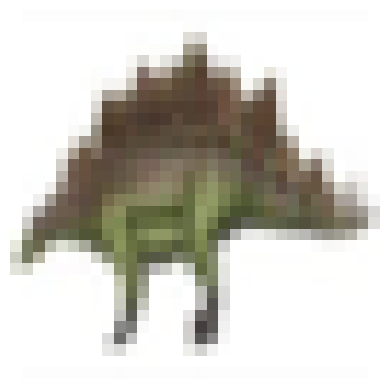

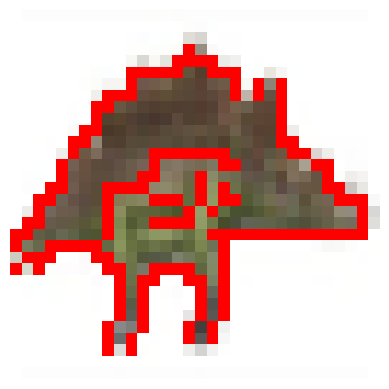

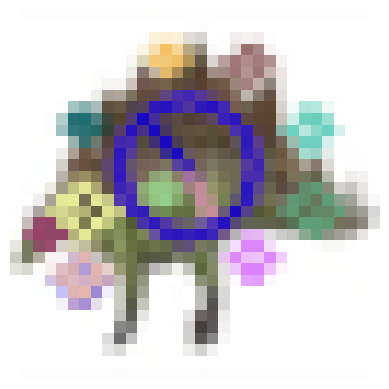

In [13]:
img_number = 1

show_image(X_train[img_number])
show_image(X_train_canny_edge[img_number])
show_image(X_train_sift_transform[img_number])

In [14]:
y_train = y_train.flatten()
y_test = y_test.flatten()

In [15]:
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

We apply one hot encoding to the target labels

In [16]:
y_train = to_categorical(y_train, num_classes=20)
y_test = to_categorical(y_test, num_classes=20)

In [17]:
len(X_train), len(y_train), len(X_test), len(y_test)

(50000, 50000, 10000, 10000)

### Inception

#### Preprocessing

We apply the proper preprocessing to the data for the inception model. We also preprocess the canny and sift dataset

In [18]:
scaled_X_train = keras.applications.inception_v3.preprocess_input(x = X_train)
scaled_X_test = keras.applications.inception_v3.preprocess_input(x = X_test)

scaled_X_train_canny = keras.applications.inception_v3.preprocess_input(x = X_train_canny_edge)
scaled_X_test_canny = keras.applications.inception_v3.preprocess_input(x = X_test_canny_edge)

scaled_X_train_sift = keras.applications.inception_v3.preprocess_input(x = X_train_sift_transform)
scaled_X_test_sift = keras.applications.inception_v3.preprocess_input(x = X_test_sift_transform)

#### Creation

#### Case 1: Model with normal dataset and no training

In [15]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.InceptionV3(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model1 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

I0000 00:00:1742234081.308784  477163 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13626 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:98:00.0, compute capability: 7.5


#### Compilation

In [16]:
model1.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Testing

In [17]:
model1.evaluate(scaled_X_test, y_test)

I0000 00:00:1742234087.083271  477238 service.cc:148] XLA service 0x146768016a40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742234087.083293  477238 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2025-03-17 18:54:47.192084: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1742234087.918470  477238 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/313 ━━━━━━━━━━━━━━━━━━━━ 1:05:56 13s/step - accuracy: 0.0312 - loss: 3.0926

I0000 00:00:1742234096.755421  477238 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 129ms/step - accuracy: 0.0465 - loss: 3.1122


[3.113577127456665, 0.04699999839067459]

In [18]:
model1.save("Inception_Model1.h5")

#### Case 2: Model with normal dataset and trained but not the weights

In [19]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.InceptionV3(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model2 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [20]:
model2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [21]:
history_model2 = model2.fit(
    scaled_X_train,
    y_train,
    validation_split=0.2,
    epochs=3,
)

Epoch 1/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 190s 144ms/step - accuracy: 0.5998 - loss: 1.3321 - val_accuracy: 0.7046 - val_loss: 0.9440
Epoch 2/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 198s 144ms/step - accuracy: 0.7266 - loss: 0.8463 - val_accuracy: 0.7202 - val_loss: 0.8805
Epoch 3/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 202s 144ms/step - accuracy: 0.7605 - loss: 0.7283 - val_accuracy: 0.7168 - val_loss: 0.8957


#### Testing

In [22]:
model2.evaluate(scaled_X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.7089 - loss: 0.9167


[0.9075810313224792, 0.7110000252723694]

In [23]:
model2.save("Inception_Model2.h5")

<Axes: >

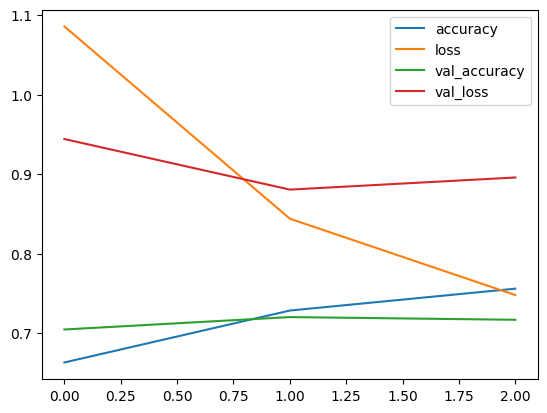

In [24]:
pd.DataFrame(history_model2.history).to_csv("Inception_Model2_Train_History.csv")
pd.DataFrame(history_model2.history).plot()

#### Case 3: Model with normal dataset and trained totally

In [25]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.InceptionV3(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = True

model3 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [26]:
model3.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [27]:
history_model3 = model3.fit(
    scaled_X_train,
    y_train,
    validation_split=0.2,
    epochs=3,
)

Epoch 1/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 634s 462ms/step - accuracy: 0.1925 - loss: 2.5608 - val_accuracy: 0.3615 - val_loss: 2.1978
Epoch 2/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 588s 461ms/step - accuracy: 0.4452 - loss: 1.6998 - val_accuracy: 0.4785 - val_loss: 1.6877
Epoch 3/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 621s 460ms/step - accuracy: 0.5623 - loss: 1.3418 - val_accuracy: 0.5772 - val_loss: 1.3035


#### Testing

In [28]:
model3.evaluate(scaled_X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.5802 - loss: 1.2934


[1.313249945640564, 0.5738000273704529]

In [29]:
model3.save("Inception_Model3.h5")

<Axes: >

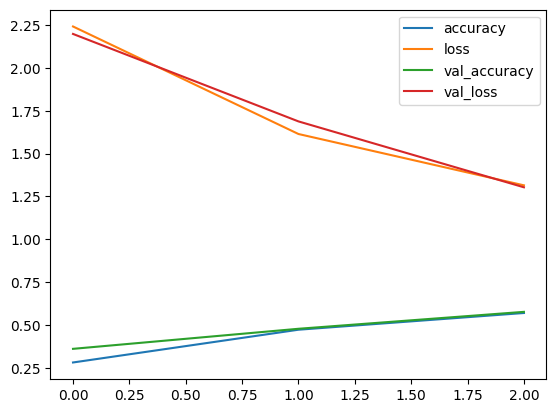

In [30]:
pd.DataFrame(history_model3.history).to_csv("Inception_Model3_Train_History.csv")
pd.DataFrame(history_model3.history).plot()

#### Case 4: Model with canny dataset and no trainable weights

In [31]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.InceptionV3(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model4 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [32]:
model4.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [33]:
history_model4 = model4.fit(
    scaled_X_train_canny,
    y_train,
    validation_split=0.2,
    epochs=6,
)

Epoch 1/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 190s 146ms/step - accuracy: 0.3761 - loss: 2.0542 - val_accuracy: 0.4870 - val_loss: 1.6344
Epoch 2/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 197s 144ms/step - accuracy: 0.5094 - loss: 1.5401 - val_accuracy: 0.5045 - val_loss: 1.5605
Epoch 3/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 202s 144ms/step - accuracy: 0.5426 - loss: 1.4173 - val_accuracy: 0.5218 - val_loss: 1.5133
Epoch 4/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 202s 144ms/step - accuracy: 0.5743 - loss: 1.3230 - val_accuracy: 0.5253 - val_loss: 1.5143
Epoch 5/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 202s 144ms/step - accuracy: 0.5987 - loss: 1.2519 - val_accuracy: 0.5374 - val_loss: 1.4668
Epoch 6/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 202s 144ms/step - accuracy: 0.6192 - loss: 1.1801 - val_accuracy: 0.5276 - val_loss: 1.5446


#### Testing

In [34]:
model4.evaluate(scaled_X_test_canny, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.5333 - loss: 1.5200


[1.5248886346817017, 0.5299999713897705]

In [35]:
model4.save("Inception_Model4.h5")

<Axes: >

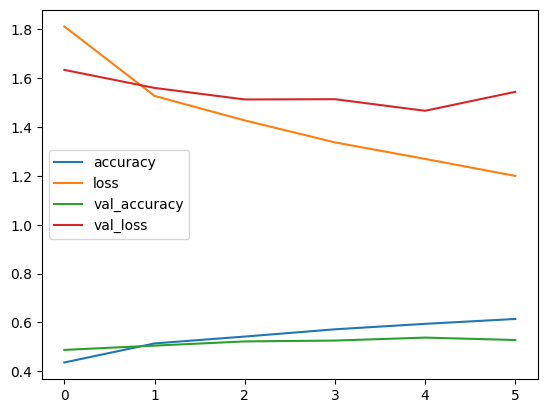

In [36]:
pd.DataFrame(history_model4.history).to_csv("Inception_Model4_Train_History.csv")
pd.DataFrame(history_model4.history).plot()

#### Case 5: Model with sift dataset and no trainable weights

In [37]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.InceptionV3(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model5 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [38]:
model5.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [39]:
history_model5 = model5.fit(
    scaled_X_train_sift,
    y_train,
    validation_split=0.2,
    epochs=6,
)

Epoch 1/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 191s 146ms/step - accuracy: 0.3923 - loss: 2.0201 - val_accuracy: 0.4968 - val_loss: 1.5908
Epoch 2/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 196s 144ms/step - accuracy: 0.5312 - loss: 1.4815 - val_accuracy: 0.5223 - val_loss: 1.4867
Epoch 3/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 202s 144ms/step - accuracy: 0.5632 - loss: 1.3712 - val_accuracy: 0.5375 - val_loss: 1.4884
Epoch 4/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 202s 144ms/step - accuracy: 0.5795 - loss: 1.3022 - val_accuracy: 0.5471 - val_loss: 1.4462
Epoch 5/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 202s 144ms/step - accuracy: 0.6008 - loss: 1.2327 - val_accuracy: 0.5410 - val_loss: 1.4678
Epoch 6/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 202s 144ms/step - accuracy: 0.6200 - loss: 1.1665 - val_accuracy: 0.5531 - val_loss: 1.4516


#### Testing

In [40]:
model5.evaluate(scaled_X_test_sift, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.5458 - loss: 1.4450


[1.4464223384857178, 0.5432000160217285]

In [41]:
model5.save("Inception_Model5.h5")

<Axes: >

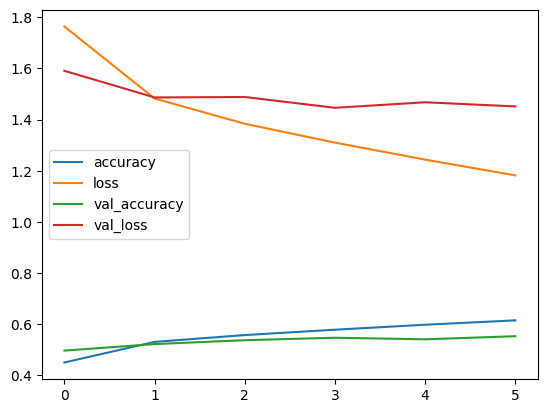

In [42]:
pd.DataFrame(history_model5.history).to_csv("Inception_Model5_Train_History.csv")
pd.DataFrame(history_model5.history).plot()

---

### Xception

#### Preprocessing

We apply the proper preprocessing to the data and also to the sift and canny dataset

In [43]:
scaled_X_train = keras.applications.xception.preprocess_input(x = X_train)
scaled_X_test = keras.applications.xception.preprocess_input(x = X_test)

scaled_X_train_canny = keras.applications.xception.preprocess_input(x = X_train_canny_edge)
scaled_X_test_canny = keras.applications.xception.preprocess_input(x = X_test_canny_edge)

scaled_X_train_sift = keras.applications.xception.preprocess_input(x = X_train_sift_transform)
scaled_X_test_sift = keras.applications.xception.preprocess_input(x = X_test_sift_transform)

#### Creation

#### Case 1: Model with normal dataset and no training

In [44]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.Xception(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model1 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [45]:
model1.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Testing

In [46]:
model1.evaluate(scaled_X_test, y_test)

2025-03-17 20:19:39.905170: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 17.43GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.0557 - loss: 3.0193  

2025-03-17 20:21:09.694893: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 17.06GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


313/313 ━━━━━━━━━━━━━━━━━━━━ 104s 283ms/step - accuracy: 0.0557 - loss: 3.0193


[3.013486623764038, 0.05810000002384186]

In [47]:
model1.save("Model1_xception.h5")

#### Case 2: Model with normal dataset and trained but not the weights

In [48]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.Xception(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model2 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [49]:
model2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [50]:
history_model2 = model2.fit(
    scaled_X_train,
    y_train,
    validation_split=0.2,
    epochs=3,
)

Epoch 1/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 471s 373ms/step - accuracy: 0.6433 - loss: 1.1511 - val_accuracy: 0.7414 - val_loss: 0.8288
Epoch 2/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 438s 323ms/step - accuracy: 0.7767 - loss: 0.6937 - val_accuracy: 0.7472 - val_loss: 0.8237
Epoch 3/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 443s 324ms/step - accuracy: 0.8151 - loss: 0.5629 - val_accuracy: 0.7631 - val_loss: 0.7708


#### Testing

In [51]:
model2.evaluate(scaled_X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 261ms/step - accuracy: 0.7606 - loss: 0.7797 


[0.7749165892601013, 0.760699987411499]

In [52]:
model2.save("Model2_xception.h5")

<Axes: >

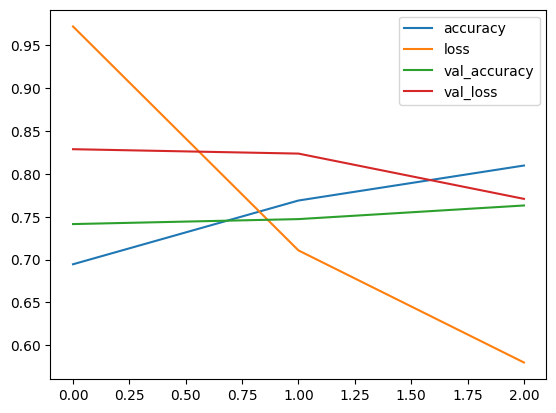

In [53]:
pd.DataFrame(history_model2.history).to_csv("Xception_Model2_Train_History.csv")
pd.DataFrame(history_model2.history).plot()

#### Case 3: Model with normal dataset and trained totally

In [54]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.Xception(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = True

model3 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [55]:
model3.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [56]:
history_model3 = model3.fit(
    scaled_X_train,
    y_train,
    validation_split=0.2,
    epochs=3,
)

Epoch 1/3


2025-03-17 20:46:19.140811: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng18{k11=0} for conv (f32[128,1,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,157,157]{3,2,1,0}, f32[32,128,157,157]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=128, custom_call_target="__cudnn$convBackwardFilter", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-03-17 20:46:19.232041: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.09129597s
Trying algorithm eng18{k11=0} for conv (f32[128,1,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,157,157]{3,2,1,0}, f32[32,128,157,157]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=128, custom_call_target="__cudnn$convB

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1315s 1s/step - accuracy: 0.4662 - loss: 1.7191 - val_accuracy: 0.6385 - val_loss: 1.1520
Epoch 2/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1308s 1s/step - accuracy: 0.7308 - loss: 0.8367 - val_accuracy: 0.7073 - val_loss: 0.9371
Epoch 3/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1223s 965ms/step - accuracy: 0.8058 - loss: 0.6049 - val_accuracy: 0.7228 - val_loss: 0.9319


#### Testing

In [57]:
model3.evaluate(scaled_X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 257ms/step - accuracy: 0.7124 - loss: 0.9361 


[0.9303835034370422, 0.7134000062942505]

In [58]:
model3.save("Model3_xception.h5")

<Axes: >

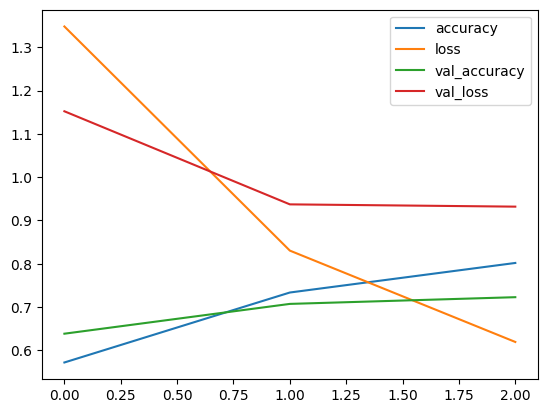

In [59]:
pd.DataFrame(history_model3.history).to_csv("Xception_Model3_Train_History.csv")
pd.DataFrame(history_model3.history).plot()

#### Case 4: Model with canny dataset and no trainable weights

In [60]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.Xception(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model4 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [61]:
model4.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [62]:
history_model4 = model4.fit(
    scaled_X_train_canny,
    y_train,
    validation_split=0.2,
    epochs=6,
)

Epoch 1/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 474s 376ms/step - accuracy: 0.4123 - loss: 1.8806 - val_accuracy: 0.4999 - val_loss: 1.5722
Epoch 2/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 497s 373ms/step - accuracy: 0.5496 - loss: 1.4095 - val_accuracy: 0.5273 - val_loss: 1.5104
Epoch 3/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 502s 373ms/step - accuracy: 0.5945 - loss: 1.2567 - val_accuracy: 0.5468 - val_loss: 1.4369
Epoch 4/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 502s 373ms/step - accuracy: 0.6372 - loss: 1.1339 - val_accuracy: 0.5492 - val_loss: 1.4658
Epoch 5/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 502s 373ms/step - accuracy: 0.6668 - loss: 1.0228 - val_accuracy: 0.5578 - val_loss: 1.4447
Epoch 6/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 502s 373ms/step - accuracy: 0.7077 - loss: 0.8988 - val_accuracy: 0.5650 - val_loss: 1.4484


#### Testing

In [63]:
model4.evaluate(scaled_X_test_canny, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 255ms/step - accuracy: 0.5636 - loss: 1.4439 


[1.4243310689926147, 0.5659999847412109]

In [64]:
model4.save("Model4_xception.h5")

<Axes: >

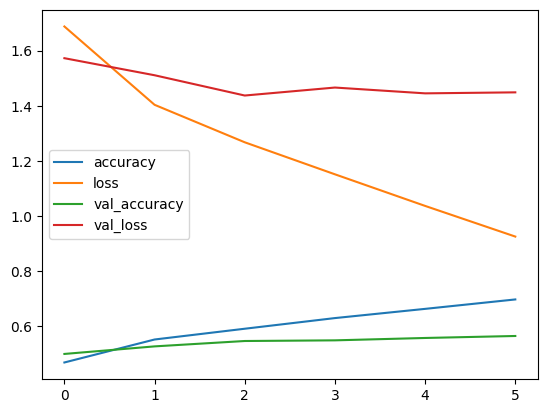

In [65]:
pd.DataFrame(history_model4.history).to_csv("Xception_Model4_Train_History.csv")
pd.DataFrame(history_model4.history).plot()

#### Case 5: Model with sift dataset and no trainable weights

In [66]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.Xception(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model5 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [67]:
model5.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [68]:
history_model5 = model5.fit(
    scaled_X_train_sift,
    y_train,
    validation_split=0.2,
    epochs=6,
)

Epoch 1/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 474s 376ms/step - accuracy: 0.4351 - loss: 1.8192 - val_accuracy: 0.5143 - val_loss: 1.5119
Epoch 2/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 497s 373ms/step - accuracy: 0.5575 - loss: 1.3747 - val_accuracy: 0.5310 - val_loss: 1.4910
Epoch 3/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 502s 373ms/step - accuracy: 0.6051 - loss: 1.2173 - val_accuracy: 0.5491 - val_loss: 1.4288
Epoch 4/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 502s 373ms/step - accuracy: 0.6396 - loss: 1.1160 - val_accuracy: 0.5466 - val_loss: 1.4588
Epoch 5/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 502s 373ms/step - accuracy: 0.6798 - loss: 0.9810 - val_accuracy: 0.5542 - val_loss: 1.4222
Epoch 6/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 502s 373ms/step - accuracy: 0.7188 - loss: 0.8595 - val_accuracy: 0.5624 - val_loss: 1.4787


#### Testing

In [69]:
model5.evaluate(scaled_X_test_sift, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 255ms/step - accuracy: 0.5633 - loss: 1.4880 


[1.4772876501083374, 0.5654000043869019]

In [70]:
model5.save("Model5_xception.h5")

<Axes: >

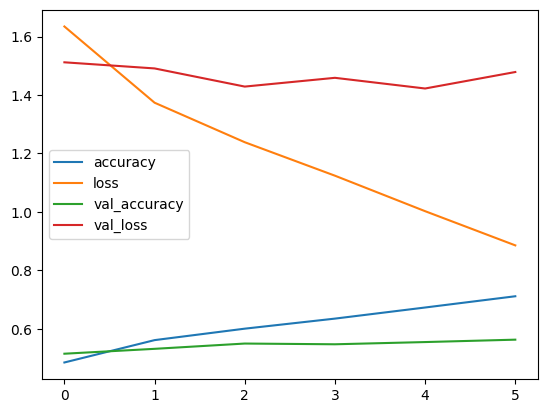

In [71]:
pd.DataFrame(history_model5.history).to_csv("Xception_Model5_Train_History.csv")
pd.DataFrame(history_model5.history).plot()

---

### Residual

#### Preprocessing

We apply again the correct preprocessing and also to the canny and sift dataset

In [72]:
scaled_X_train = keras.applications.resnet50.preprocess_input(x = X_train)
scaled_X_test = keras.applications.resnet50.preprocess_input(x = X_test)

scaled_X_train_canny = keras.applications.resnet50.preprocess_input(x = X_train_canny_edge)
scaled_X_test_canny = keras.applications.resnet50.preprocess_input(x = X_test_canny_edge)

scaled_X_train_sift = keras.applications.resnet50.preprocess_input(x = X_train_sift_transform)
scaled_X_test_sift = keras.applications.resnet50.preprocess_input(x = X_test_sift_transform)

#### Creation

#### Case 1: Model with normal dataset and no training

In [73]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model1 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [74]:
model1.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Testing

In [75]:
model1.evaluate(scaled_X_test, y_test)

2025-03-17 23:33:45.249385: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[32,64,80,80]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,80,80]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-03-17 23:33:46.281447: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[32,128,40,40]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,40,40]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActi

312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.0405 - loss: 3.4734 

2025-03-17 23:34:38.853730: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,64,80,80]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,80,80]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-03-17 23:34:39.449895: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,128,40,40]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,128,40,40]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActi

313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 167ms/step - accuracy: 0.0405 - loss: 3.4734


[3.4657952785491943, 0.03970000147819519]

In [76]:
model1.save("Model1_resnet.h5")

#### Case 2: Model with normal dataset and trained but not the weights

In [77]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model2 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [78]:
model2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [79]:
history_model2 = model2.fit(
    scaled_X_train,
    y_train,
    validation_split=0.2,
    epochs=3,
)

Epoch 1/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 282s 219ms/step - accuracy: 0.6270 - loss: 1.2151 - val_accuracy: 0.7464 - val_loss: 0.7819
Epoch 2/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 317s 218ms/step - accuracy: 0.7742 - loss: 0.6857 - val_accuracy: 0.7563 - val_loss: 0.7680
Epoch 3/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 217ms/step - accuracy: 0.8070 - loss: 0.5705 - val_accuracy: 0.7690 - val_loss: 0.7427


#### Testing

In [80]:
model2.evaluate(scaled_X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 151ms/step - accuracy: 0.7586 - loss: 0.7621


[0.7620345950126648, 0.7594000101089478]

In [81]:
model2.save("Model2_resnet.h5")

<Axes: >

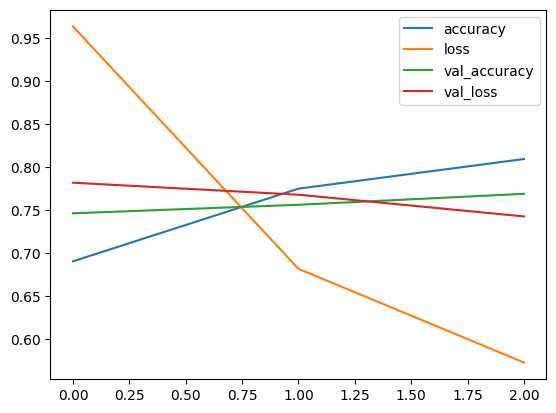

In [82]:
pd.DataFrame(history_model2.history).to_csv("Residual_Model2_Train_History.csv")
pd.DataFrame(history_model2.history).plot()

#### Case 3: Model with normal dataset and trained totally

In [19]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = True

model3 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

I0000 00:00:1742314606.613959 1412680 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13760 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:98:00.0, compute capability: 7.5


#### Compilation

In [20]:
model3.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [21]:
history_model3 = model3.fit(
    scaled_X_train,
    y_train,
    validation_split=0.2,
    epochs=3,
)

Epoch 1/3


I0000 00:00:1742314631.649458 1412890 service.cc:148] XLA service 0x154e98016dd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742314631.649804 1412890 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2025-03-18 17:17:12.323596: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1742314635.296286 1412890 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-03-18 17:17:18.107513: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[32,64,80,80]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,80,80]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activati

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.2365 - loss: 2.4810  

2025-03-18 17:29:40.219688: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,64,80,80]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,80,80]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-03-18 17:29:40.803011: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,128,40,40]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,128,40,40]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActi

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 802s 603ms/step - accuracy: 0.2366 - loss: 2.4808 - val_accuracy: 0.4280 - val_loss: 1.7940
Epoch 2/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 778s 605ms/step - accuracy: 0.4846 - loss: 1.5893 - val_accuracy: 0.5585 - val_loss: 1.3773
Epoch 3/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 800s 604ms/step - accuracy: 0.6013 - loss: 1.2174 - val_accuracy: 0.5790 - val_loss: 1.3661


#### Testing

In [22]:
model3.evaluate(scaled_X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 149ms/step - accuracy: 0.5770 - loss: 1.3648


[1.3565665483474731, 0.5751000046730042]

In [23]:
model3.save("Model3_resnet.h5")

<Axes: >

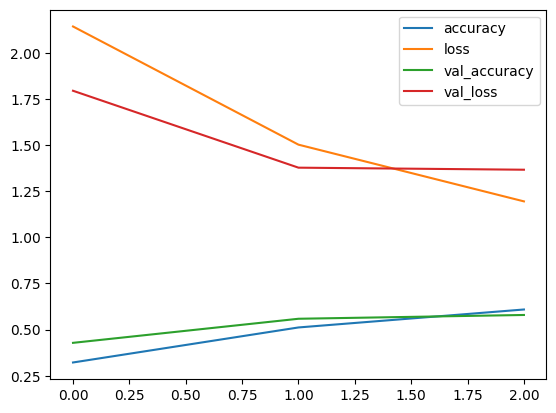

In [24]:
pd.DataFrame(history_model3.history).to_csv("Residual_Model3_Train_History.csv")
pd.DataFrame(history_model3.history).plot()

#### Case 4: Model with canny dataset and no trainable weights

In [25]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model4 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [26]:
model4.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [27]:
history_model4 = model4.fit(
    scaled_X_train_canny,
    y_train,
    validation_split=0.2,
    epochs=3,
)

Epoch 1/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 278s 217ms/step - accuracy: 0.1067 - loss: 2.9630 - val_accuracy: 0.1440 - val_loss: 2.7398
Epoch 2/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 318s 216ms/step - accuracy: 0.1636 - loss: 2.7063 - val_accuracy: 0.1827 - val_loss: 2.6435
Epoch 3/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 216ms/step - accuracy: 0.1888 - loss: 2.6266 - val_accuracy: 0.2152 - val_loss: 2.5645


#### Testing

In [28]:
model4.evaluate(scaled_X_test_canny, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 148ms/step - accuracy: 0.2204 - loss: 2.5492


[2.560342788696289, 0.2150000035762787]

In [29]:
model4.save("Model4_resnet.h5")

<Axes: >

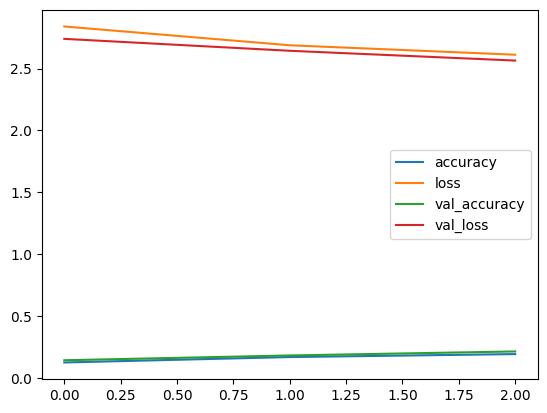

In [30]:
pd.DataFrame(history_model4.history).to_csv("Residual_Model4_Train_History.csv")
pd.DataFrame(history_model4.history).plot()

#### Case 5: Model with sift dataset and no trainable weights

In [31]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model5 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [32]:
model5.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [33]:
history_model5 = model5.fit(
    scaled_X_train_sift,
    y_train,
    validation_split=0.2,
    epochs=6,
)

Epoch 1/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 278s 217ms/step - accuracy: 0.0633 - loss: 3.0574 - val_accuracy: 0.0842 - val_loss: 2.9359
Epoch 2/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 318s 216ms/step - accuracy: 0.0937 - loss: 2.9183 - val_accuracy: 0.1112 - val_loss: 2.8633
Epoch 3/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 216ms/step - accuracy: 0.1214 - loss: 2.8490 - val_accuracy: 0.1346 - val_loss: 2.8023
Epoch 4/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 216ms/step - accuracy: 0.1345 - loss: 2.7943 - val_accuracy: 0.1292 - val_loss: 2.7796
Epoch 5/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 216ms/step - accuracy: 0.1489 - loss: 2.7478 - val_accuracy: 0.1508 - val_loss: 2.7323
Epoch 6/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 216ms/step - accuracy: 0.1565 - loss: 2.7253 - val_accuracy: 0.1323 - val_loss: 2.8029


#### Testing

In [34]:
model5.evaluate(scaled_X_test_sift, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 148ms/step - accuracy: 0.1325 - loss: 2.8090


[2.8028602600097656, 0.13279999792575836]

In [35]:
model5.save("Model5_resnet.h5")

<Axes: >

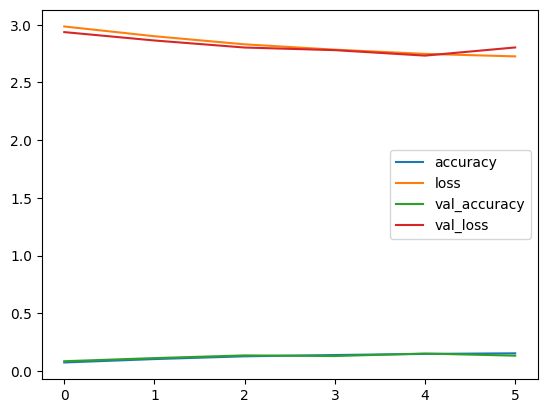

In [36]:
pd.DataFrame(history_model5.history).to_csv("Residual_Model5_Train_History.csv")
pd.DataFrame(history_model5.history).plot()